# Experimento 14

## Entrenamiento con pipeline escogida

Tras los experimentos anteriores se llega a las siguientes conclusiones:

- Existe una tendencia generalizada al sobreajuste con los datos disponibles. La estrategia que se va a escoger para intentar mejorar este aspecto es una pipeline variada para aumentar la variabilidad del dataset por epochs.
- El modelo con kernel(7,3) parece obtener unas mejores métricas pero el incremento en coste computacional no es adecuado para el aprendizaje en _edge computing_ que es foco del trabajo. Se considera que el modelo original proporciona converge de manera rápida y con las aumentaciones pueden obtenerse resultados similares.
- Se seleccionan las siguientes aumentaciones para el pipeline, según lo descrito en el documento principal:
    -  Time shift
    -  Speed perturb
    -  Random gain
    -  Reverb
    -  Eq and compress

In [1]:
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from signal_grad_cam.pytorch_cam_builder import TorchCamBuilder

I0000 00:00:1781121713.768670    6837 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781121713.799676    6837 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781121714.623596    6837 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781121714.623858    6837 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

# Cambios MELs
SAMPLE_RATE = 16000
N_MELS =128
N_FFT = int(768)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(100)

In [3]:
final_path = '14B-entrenamiento_2D_pipelineXAI/final'
checkpoints_path = '14B-entrenamiento_2D_pipelineXAI/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/14B-entrenamiento_2D_pipelineXAI')
batch_size = 200
epochs = 10

In [4]:
%%capture
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,
        with_log = True,
        device = DEVICE,
        mode = "training",
        augmentation_probs = {
            "time_shift" : 0.6,
            "speed_perturb" : 0.5,
            "random_gain" : 0.3,
            "reverb" : 0.2,
            "basic_eq_and_compress" : 0.15})

preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE)
# Modelo
model = AudioResNetModel(dims=2, num_classes=NUM_CLASSES).get_model()
model.to(DEVICE)

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

In [6]:
trainer = Trainer(model=model, train_loader=train_loader, 
                  val_loader=val_loader, preprocessor=preprocessor_train, 
                  persister=persister, device=DEVICE, epochs=epochs)                     
trainer.fit(resume=False)

Epoch::   0%|          | 0/10 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 1/10
  Train - Pérdida: 0.7202, Accuracy: 0.7943, F1-score: 0.7863
  Val   - Pérdida: 0.4050, Accuracy: 0.8785, F1-score: 0.8652


Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

...

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 9/10
  Train - Pérdida: 0.1131, Accuracy: 0.9639, F1-score: 0.9609
  Val   - Pérdida: 0.3295, Accuracy: 0.9128, F1-score: 0.9089


Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 10/10
  Train - Pérdida: 0.1057, Accuracy: 0.9665, F1-score: 0.9638
  Val   - Pérdida: 0.2728, Accuracy: 0.9214, F1-score: 0.9156


In [7]:
learning_rate = 1e-4
trainer = Trainer(model=model, learning_rate = 1e-4, train_loader=train_loader, 
                  val_loader=val_loader, preprocessor=preprocessor_train, 
                  persister=persister, device=DEVICE, epochs=20, resume_from=f"{final_path}/final_model.pt")                     
trainer.fit(resume=True)

Cargado desde 14B-entrenamiento_2D_pipelineXAI/final/final_model.pt. Comenzamos en epoch 11
Cargado desde 14B-entrenamiento_2D_pipelineXAI/final/final_model.pt. Comenzamos en epoch 11


Epoch::   0%|          | 0/10 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 11/20
  Train - Pérdida: 0.0620, Accuracy: 0.9814, F1-score: 0.9800
  Val   - Pérdida: 0.1712, Accuracy: 0.9518, F1-score: 0.9472


...

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 19/20
  Train - Pérdida: 0.0289, Accuracy: 0.9917, F1-score: 0.9910
  Val   - Pérdida: 0.2088, Accuracy: 0.9502, F1-score: 0.9444


Batches entrenamiento:   0%|          | 0/371 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/53 [00:00<?, ?it/s]

Epoch 20/20
  Train - Pérdida: 0.0268, Accuracy: 0.9924, F1-score: 0.9917
  Val   - Pérdida: 0.2102, Accuracy: 0.9496, F1-score: 0.9443


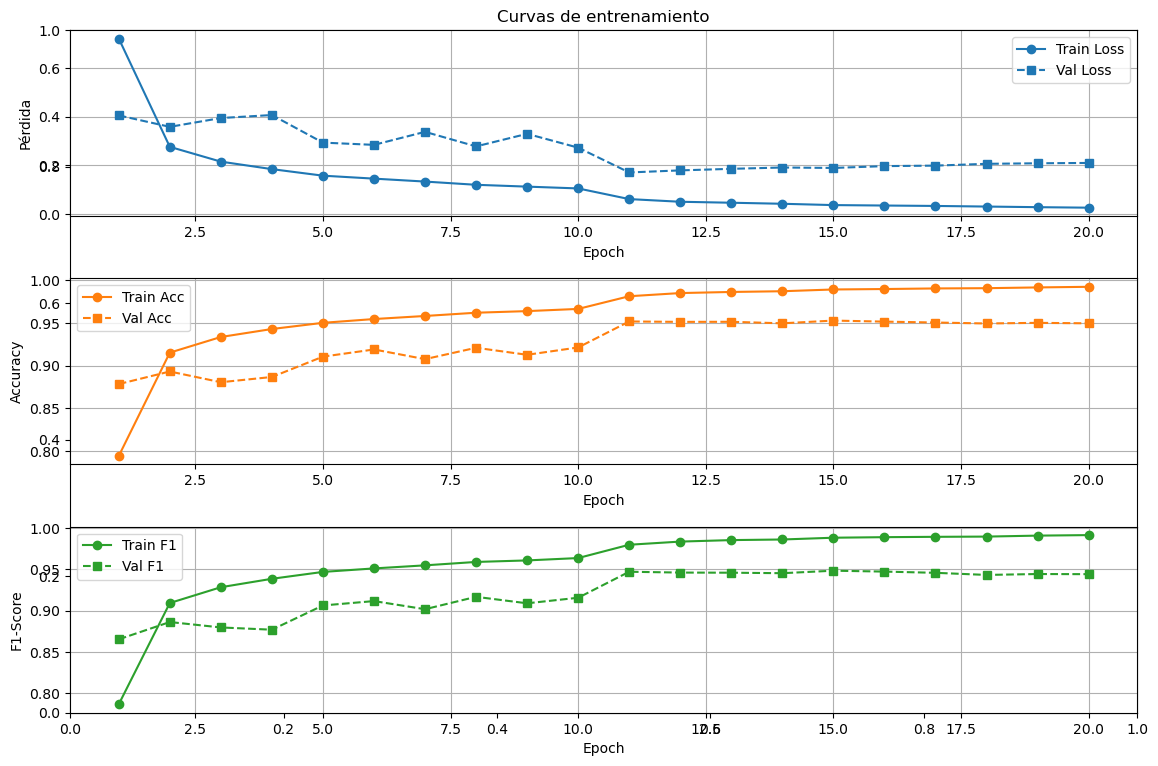

In [6]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

La mejor métrica hasta el momento. Se ve cómo la curva se estabiliza  en la epoch 11, donde se ha bajado el leaning rate de 1e-3 a 1e-4. Vamos a quedarnos con el modelo de mejores métricas en f1.

In [7]:
df = pd.DataFrame(loaded_pt['history'])
df.index = df.index+1
print(df)

    train_loss  train_acc  train_f1  val_loss   val_acc    val_f1  epoch_time
1     0.720205   0.794271  0.786309  0.405041  0.878473  0.865156  192.672257
2     0.276129   0.915298  0.909233  0.358132  0.893215  0.886147  191.965296
3     0.215503   0.933615  0.928407  0.394256  0.880646  0.879566  192.736974
4     0.184797   0.942969  0.938651  0.406531  0.886789  0.876829  193.307178
5     0.157971   0.950218  0.946995  0.293463  0.910603  0.906266  194.320541
6     0.145841   0.954645  0.951236  0.284265  0.919013  0.911574  194.866704
7     0.133799   0.958236  0.954956  0.337628  0.907673  0.901707  195.159506
8     0.120589   0.962043  0.959097  0.277950  0.920998  0.916752  195.136449
9     0.113072   0.963932  0.960941  0.329514  0.912776  0.908884  195.975308
10    0.105681   0.966497  0.963816  0.272765  0.921376  0.915631  195.446703
11    0.061998   0.981359  0.979975  0.171169  0.951805  0.947187  194.601730
12    0.051026   0.985071  0.983814  0.179646  0.951332  0.94619

El modelo con mejores métricas de validación corresponde a la epoch 15, que cargamos.

In [8]:
%%capture
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{checkpoints_path}/best_checkpoint_epoch_15.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

**Análisis del entrenamiento**

El entrenamiento progresa de manera consistente en las medidas de train y val. El margen entre las curvas indica un ligero sobreajuste del modelo, pero siempre dentro de unas buenas medidas.

In [9]:
# Instanciamos el evaluador y computamos métricas con conjunto de test
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/53 [00:00<?, ?it/s]

Pérdida: 0.5867769617500727 Accuracy: 0.937913437913438 F1-Score: 0.9337815334879435


In [10]:
# Ratio entre f1 test y f1 en val
print("Ratio test/val F1:", f1/loaded_pt['history'].get('val_f1')[12])
print("Ratio test/val Accuracy:", accuracy/loaded_pt['history'].get('val_acc')[12])

Ratio test/val F1: 0.9870522184590965
Ratio test/val Accuracy: 0.9857965832340088


El modelo generaliza muy bien sus resultados con respecto al conjunto de test. El valor relativamente alto de la pérdida media en test nos puede indicar que la confianza del modelo en las predicciones puede haberse resentido por aumentaciones demasiado agresivas durante el entrenamiento. Una opción sería reentrenar con probabilidades más bajas para las aumentaciones de la pipeline. 

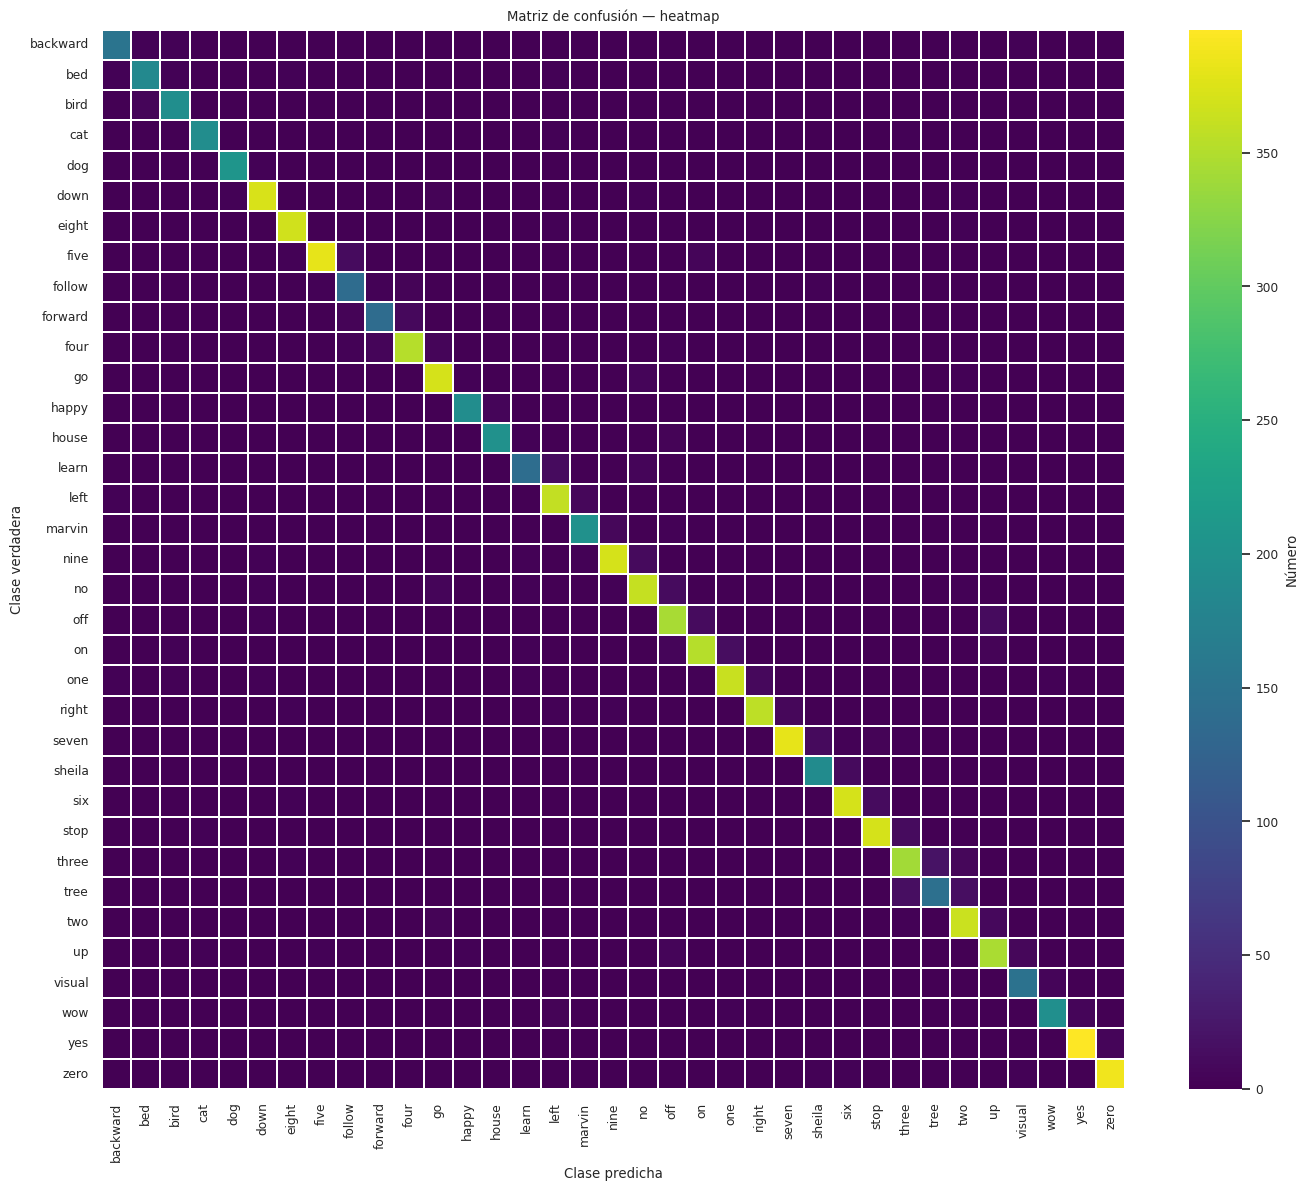

In [11]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize = (14,12))
sb.set(font_scale = 0.8)
ax = sb.heatmap(confusion_matrix,
                annot=False,
                fmt = ".2f",
                cmap = "viridis",
                cbar_kws = {"label": "Número"},
                xticklabels = label_names,
                yticklabels = label_names,
                linewidths = 0.3,
                linecolor = "white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Matriz de confusión — heatmap")
plt.tight_layout()
plt.show()
plt.rcdefaults()

No se aprecia ninguna clase especialmente problemática.

In [12]:
print("Métricas con test set:",
      "\n\nAccuracy:", accuracy, 
      "\nPrecission:", precission, 
      "\nRecall:", recall, 
      "\nPérdida media:", avg_loss, 
      "\nF1-score:", f1)

Métricas con test set: 

Accuracy: 0.937913437913438 
Precission: 0.9344858475992915 
Recall: 0.9333212369951586 
Pérdida media: 0.5867769617500727 
F1-score: 0.9337815334879435


Las métricas muestran una muy buena generalización del modelo. Llama la atención la alta medida de pérdida con el conjunto de test, que puede deberse a haber usado aumentaciones demasiado agresivas que alejan las muestras de entrenamiento de las reales a las que se va a enfrentar el modelo.

In [33]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [34]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "Grad-CAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

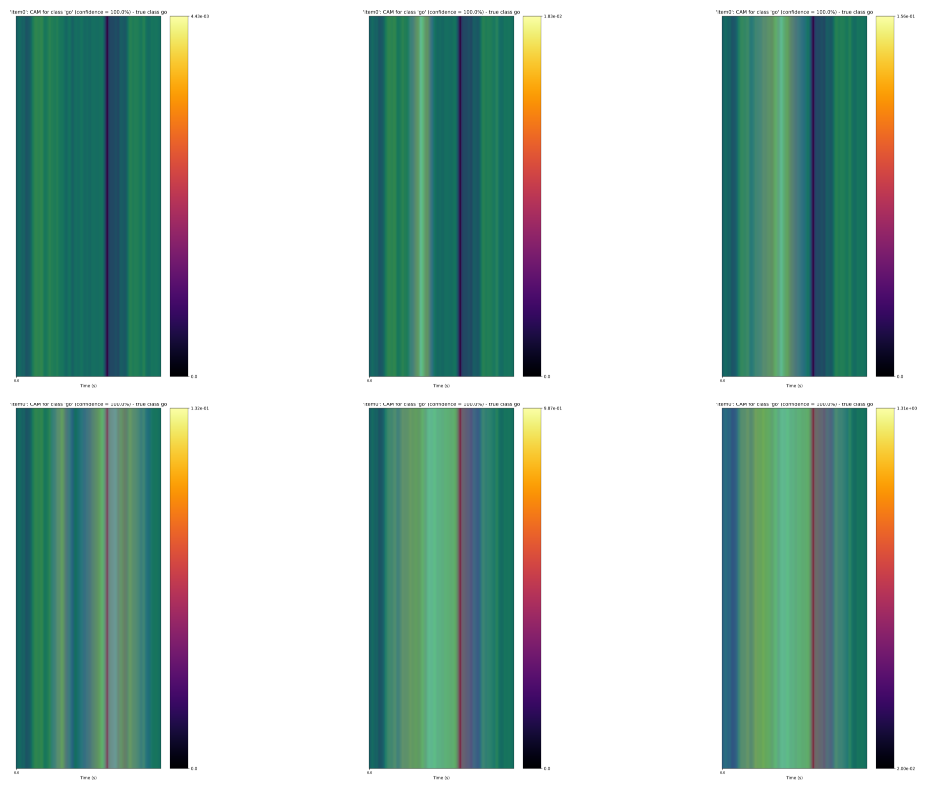

In [35]:
## Visualizamos muestra de capas
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*Grad*.png"))
show_image_grid(images_to_show)

Los CAMs son consistentes con los anteriores en esta clase, por lo que generalizamos que el modelo es coherente en sus predicciones.

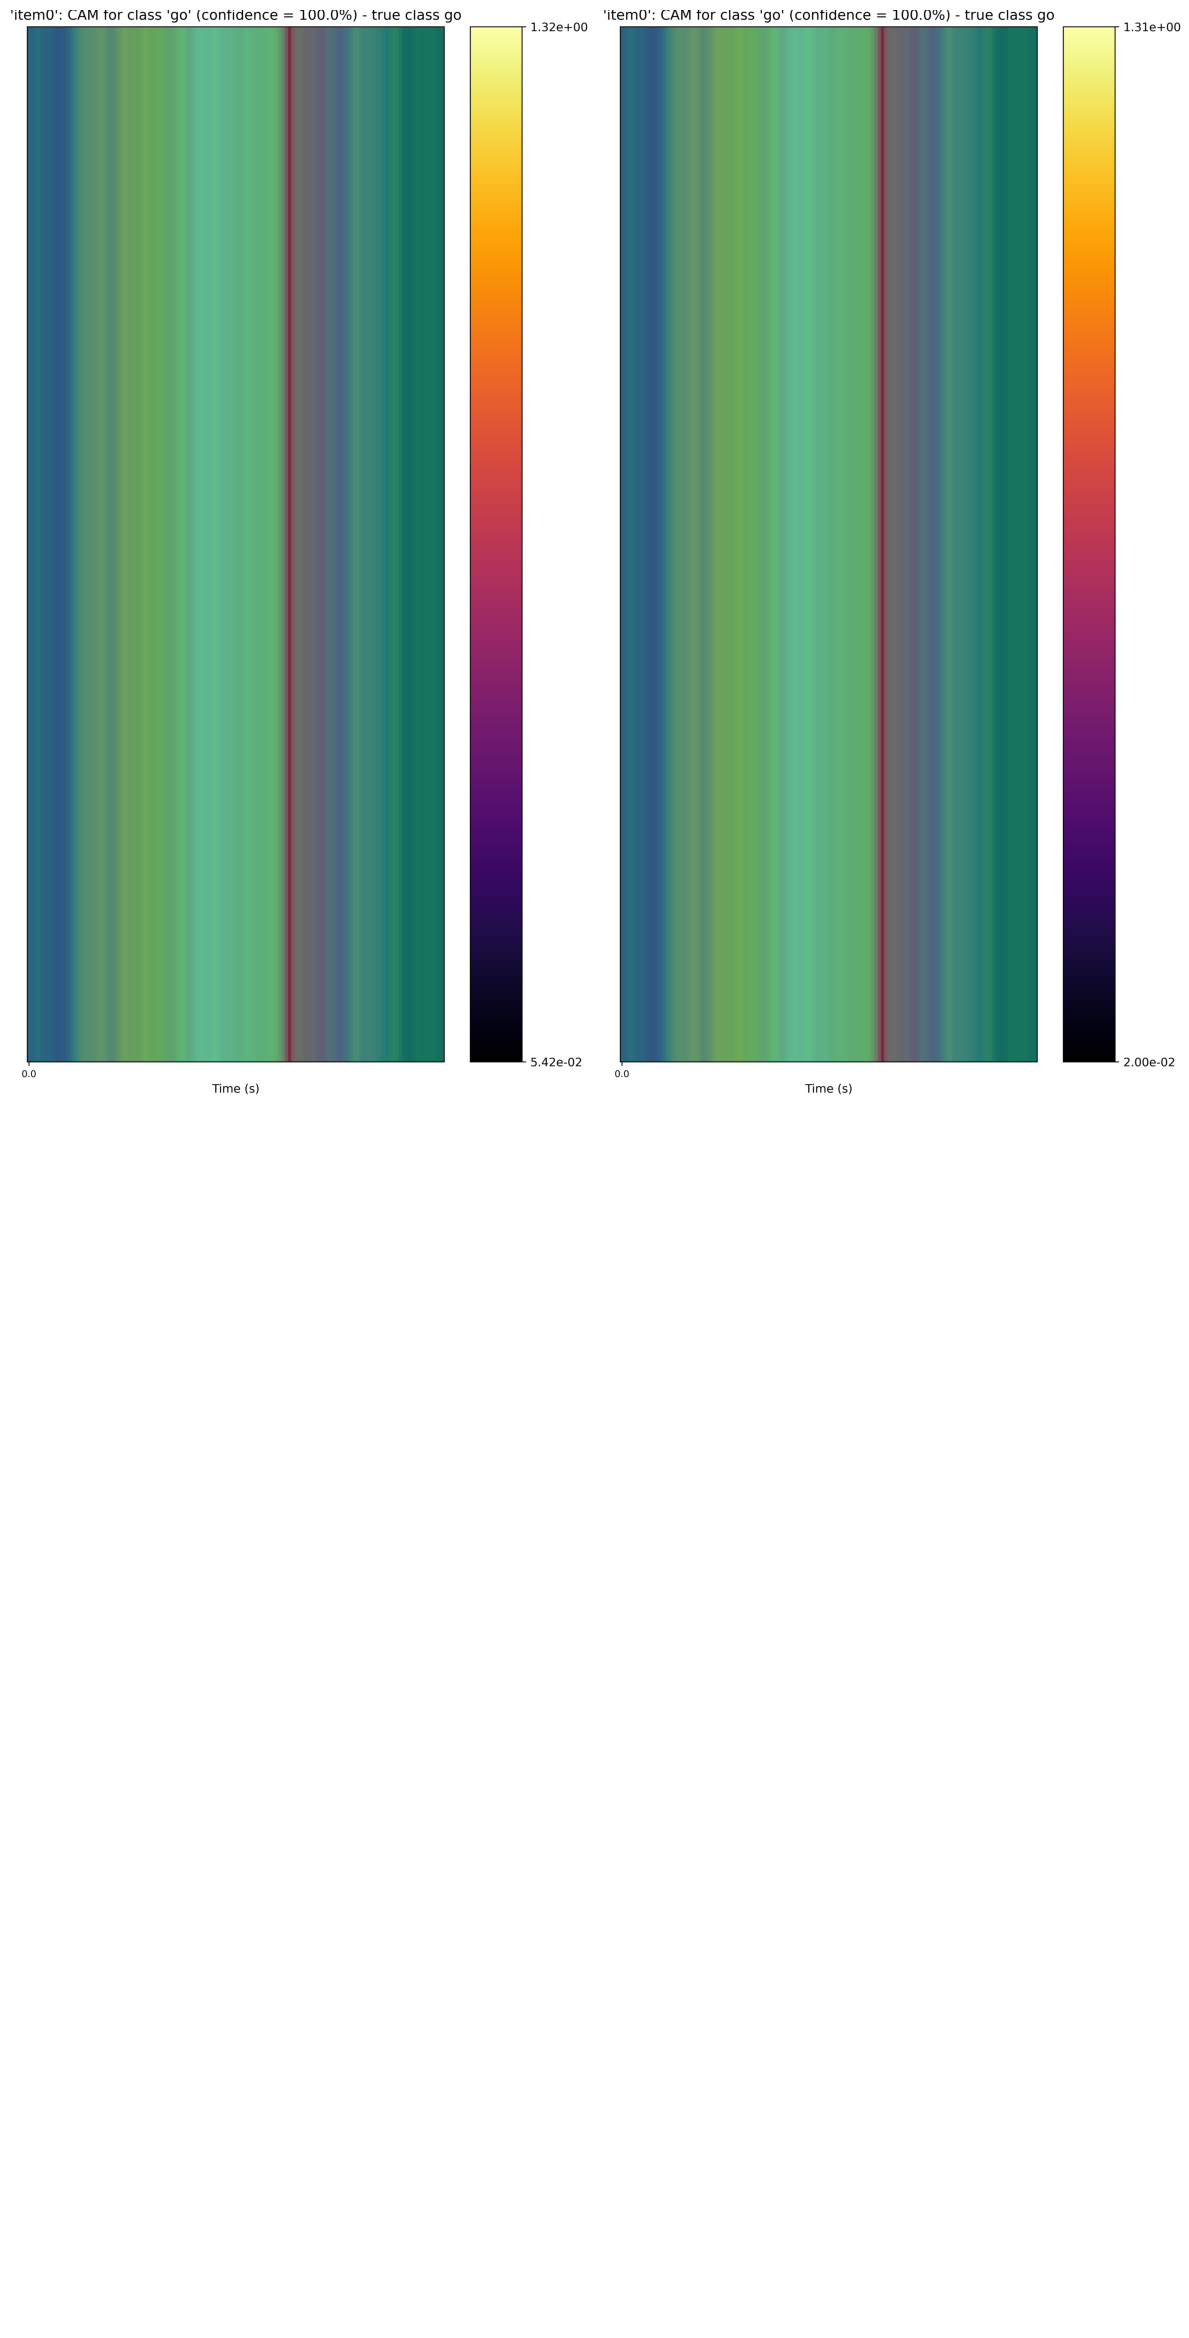

In [36]:
# CAM "GO"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18_02/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

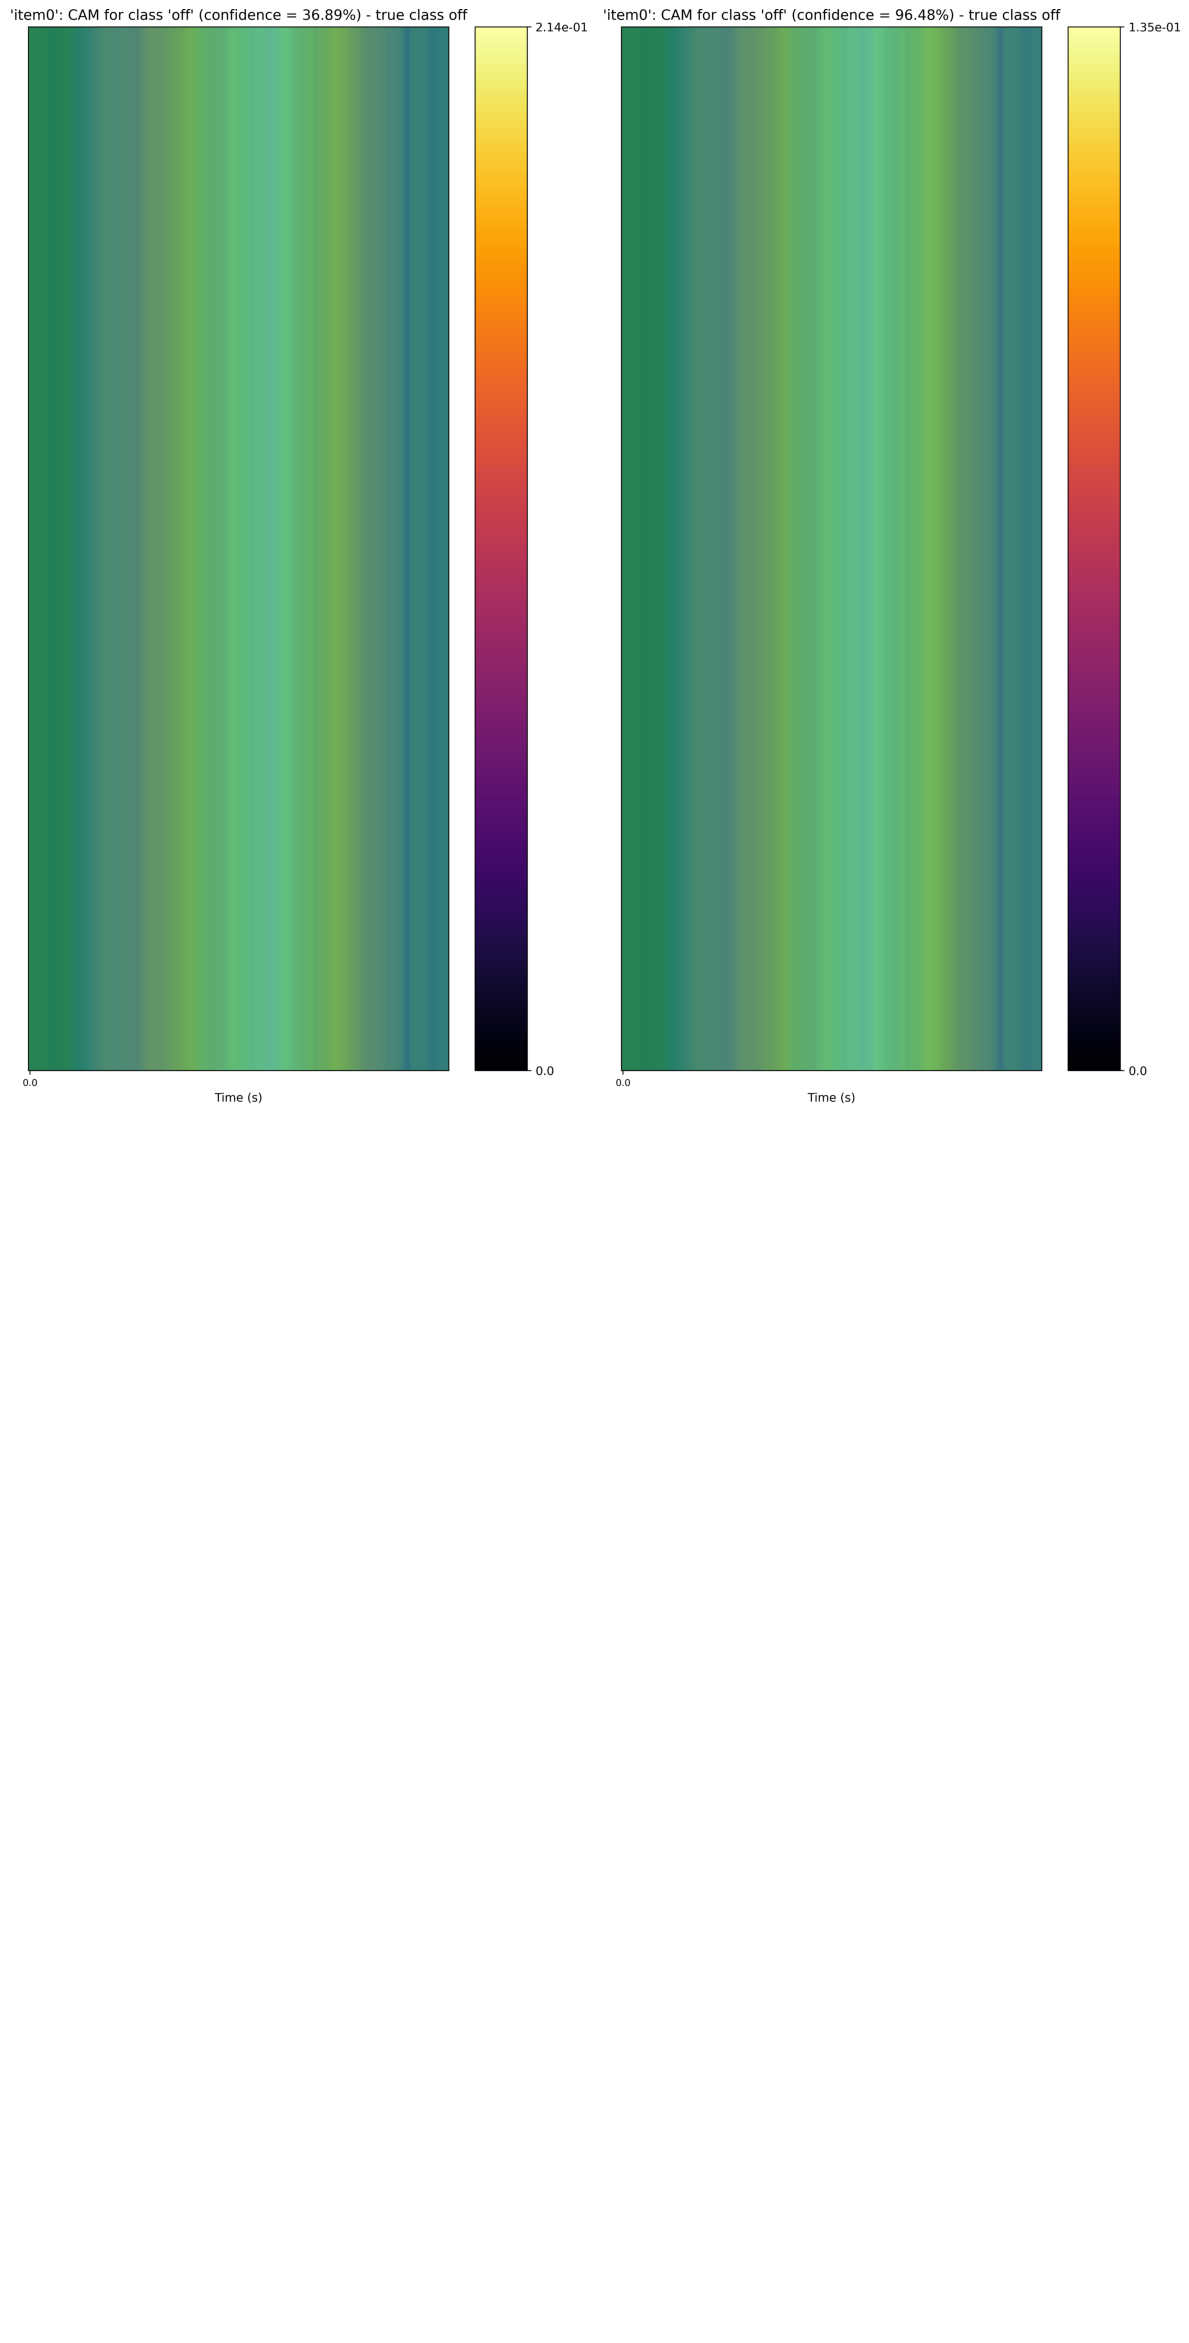

In [37]:
# CAM "OFF"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18_02/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

Las activaciones de OFF se han concretado mucho en una franja más estrecha y la confianza del modelo en esta precicción ha subido considerablemente.

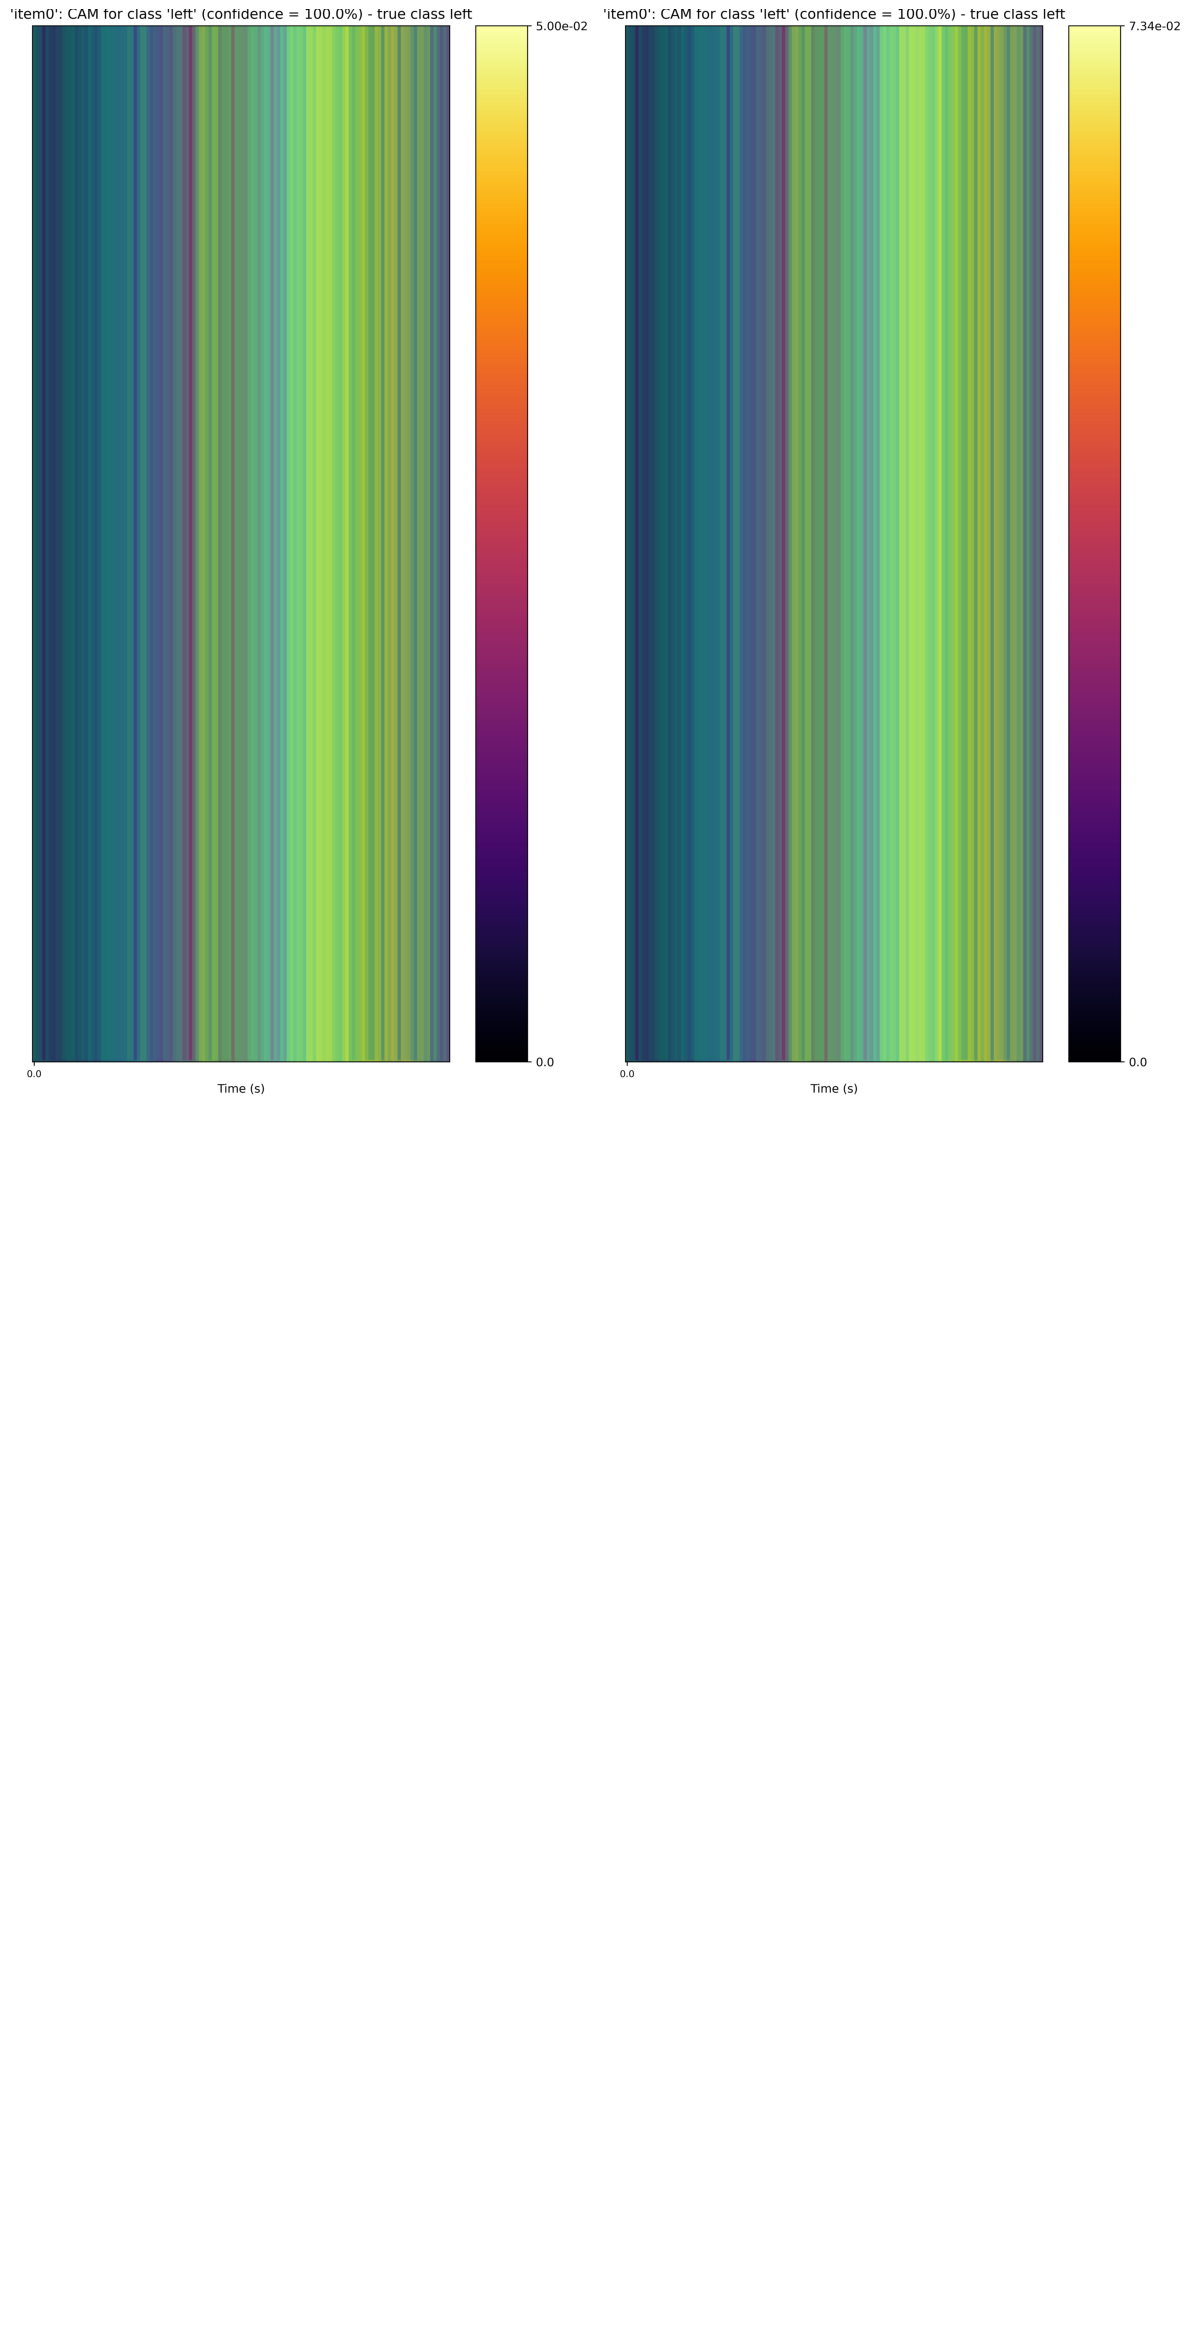

In [38]:
# CAM "LEFT"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18_02/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

La atención del modelo se mantiene consistente con el modelo de referencia (baseline v2) y las medidas de confianza de las muestras de referencia con margen de mejora aumentan.

Finalmente, vamos a estimar el coste de entrenamiento a partir del tiempo medio por epoch.

In [20]:
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
etimes = loaded_pt['history'].get('epoch_time')
avg_etime = sum(etimes)/len(etimes)
print(avg_etime)
baseline_etime = 155.78
print("El coste en tiempo por epoch es de", f"{avg_etime/baseline_etime:.2f}", "veces el de la línea de base (v2).")     

195.06832866668702
El coste en tiempo por epoch es de 1.25 veces el de la línea de base (v2).


El tiempo por epoch con esta pipeline sólo ha aumentado un 25% con respecto del de la línea de base.